# Continue U-TGV from epoch 200 to epoch 300

This notebook performs the final, **U-TGV-only** continuation. U-TV and
U-Tikhonov are already treated as converged and are not loaded for training.

| model | completed source epoch | fixed target epoch | additional epochs |
|---|---:|---:|---:|
| U-TGV | 200 | 300 | 100 |

The source is the genuine epoch-200 continuation checkpoint created by
`05b_resume_principal_models_to_300_200_300.ipynb`. It contains the network,
complete AdamW state, combined history and saved Python/NumPy/PyTorch/DataLoader
RNG states. Restoring all of these makes epochs 201–300 a direct continuation
of the existing optimisation trajectory.

The epoch-200 directory is read-only. New files are written only to:

```text
checkpoints/u_tgv_e300_resumed_from_e200/
```

The target of 300 epochs is fixed before the final benchmark. Checkpoint
selection continues to use only deterministic SeaTurtle validation PSNR.

In [1]:
from __future__ import annotations

import json
import os
import random
import shutil
import sys
import time
from argparse import Namespace
from pathlib import Path


def locate_project_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = []
    for base in (cwd, *cwd.parents):
        candidates.extend((base, base / "cleaned_pipeline"))
    for candidate in candidates:
        if (candidate / "src").is_dir() and (candidate / "scripts").is_dir():
            return candidate.resolve()
    raise FileNotFoundError(
        "Could not find cleaned_pipeline. Start Jupyter from Thesis/Python, "
        "cleaned_pipeline, or cleaned_pipeline/notebooks."
    )


PROJECT_ROOT = locate_project_root()
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)


Project root: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from IPython.display import display
from torch.utils.data import DataLoader, random_split

from src.data.denoising_dataset import FixedNoiseDataset
from src.data.seaturtle_dataset import SeaTurtleDenoisingDataset
from src.evaluation.benchmark import load_checkpoint, load_project_model
from src.evaluation.denoising_eval import (
    evaluate_denoising_model,
    summarize_results,
    unpack_model_output,
)
from src.training.denoising import (
    apply_common_defaults,
    describe_device,
    get_device,
    synchronize_device,
)

device = get_device()
print("PyTorch:", torch.__version__)
print("Device:", device)


PyTorch: 2.12.0
Device: mps


## Configuration

`TARGET_EPOCH` is the total epoch count. The source and output directories are
different by construction, so neither the 100-epoch nor 200-epoch U-TGV
experiments can be overwritten.


In [3]:
METHOD = "U-TGV"
MODEL_NAME = "u_tgv"
SOURCE_EPOCH = 200
TARGET_EPOCH = 300

SOURCE_DIR = PROJECT_ROOT / "checkpoints" / "u_tgv_e200_resumed_from_e100"
OUTPUT_DIR = PROJECT_ROOT / "checkpoints" / "u_tgv_e300_resumed_from_e200"

SOURCE_LATEST = SOURCE_DIR / "u_tgv_latest.pth"
SOURCE_BEST = SOURCE_DIR / "u_tgv_best.pth"
OUTPUT_LATEST = OUTPUT_DIR / "u_tgv_latest.pth"
OUTPUT_BEST = OUTPUT_DIR / "u_tgv_best.pth"

if SOURCE_DIR.resolve() == OUTPUT_DIR.resolve():
    raise RuntimeError("Source and output directories must be different.")

configuration = pd.DataFrame([{
    "method": METHOD,
    "source_epoch": SOURCE_EPOCH,
    "target_epoch": TARGET_EPOCH,
    "additional_epochs": TARGET_EPOCH - SOURCE_EPOCH,
    "source_latest": str(SOURCE_LATEST),
    "source_best": str(SOURCE_BEST),
    "output_directory": str(OUTPUT_DIR),
}])
display(configuration)


,method,source_epoch,target_epoch,additional_epochs,source_latest,source_best,output_directory
0,U-TGV,200,300,100,/Users/kyrillguba/Documents/Data Analytics MSc...,/Users/kyrillguba/Documents/Data Analytics MSc...,/Users/kyrillguba/Documents/Data Analytics MSc...


## Audit the epoch-200 source
This cell declares source and target epochs, protected input/output directories, run switches, and the independent continuation seed.

It fails before training unless the source really is the completed U-TGV
continuation at epoch 200, its history and validation-selected best checkpoint
agree, its AdamW state is populated, and its saved RNG state is available.

In [4]:
for path in (SOURCE_LATEST, SOURCE_BEST):
    if not path.is_file():
        raise FileNotFoundError(f"Missing required source checkpoint: {path}")

source_checkpoint = load_checkpoint(SOURCE_LATEST, "cpu")
source_best_checkpoint = load_checkpoint(SOURCE_BEST, "cpu")

if source_checkpoint.get("model_name") != MODEL_NAME:
    raise RuntimeError("The source checkpoint is not a U-TGV checkpoint.")
if int(source_checkpoint.get("epoch", -1)) != SOURCE_EPOCH:
    raise RuntimeError(
        f"Expected source epoch {SOURCE_EPOCH}, found {source_checkpoint.get('epoch')}."
    )

source_history = pd.DataFrame(source_checkpoint.get("history", []))
if len(source_history) != SOURCE_EPOCH:
    raise RuntimeError("The source history does not contain one row per epoch through 200.")
if int(source_history["epoch"].iloc[-1]) != SOURCE_EPOCH:
    raise RuntimeError("The source history does not end at epoch 200.")
if source_history["epoch"].duplicated().any():
    raise RuntimeError("The source history contains duplicate epochs.")

optimizer_state = source_checkpoint.get("optimizer_state_dict")
if not optimizer_state or not optimizer_state.get("state"):
    raise RuntimeError("The source checkpoint has no populated AdamW state.")

source_rng_state = source_checkpoint.get("continuation_rng_state")
required_rng_keys = {"python", "numpy", "torch_cpu", "loader_generator"}
if not isinstance(source_rng_state, dict) or not required_rng_keys.issubset(source_rng_state):
    raise RuntimeError(
        "The epoch-200 checkpoint lacks the saved RNG state required for exact continuation."
    )

source_continuation = source_checkpoint.get("continuation", {})
if int(source_continuation.get("target_epoch", -1)) != SOURCE_EPOCH:
    raise RuntimeError("The source is not the verified 100-to-200 continuation checkpoint.")
CONTINUATION_SEED = int(source_continuation["continuation_seed"])

source_best_index = source_history["val_psnr"].idxmax()
source_best_epoch = int(source_history.loc[source_best_index, "epoch"])
source_best_psnr = float(source_history.loc[source_best_index, "val_psnr"])
source_best_file_psnr = float(source_best_checkpoint["val_metrics"]["recon_psnr"])
if not np.isclose(source_best_psnr, source_best_file_psnr, atol=1e-10):
    raise RuntimeError("The source best checkpoint does not match the source history.")

args_from_source = source_checkpoint["args"]
locked_expectations = {
    "image_size": 256,
    "max_images": 550,
    "val_images": 50,
    "val_sigma": 0.1,
    "val_noise_seed": 10_000,
    "base_channels": 32,
    "depth": 3,
    "batch_size": 1,
    "lr": 1e-4,
    "weight_decay": 1e-5,
    "grad_clip": 1.0,
    "seed": 42,
    "num_pdhg_iters": 64,
}
for field, expected in locked_expectations.items():
    observed = args_from_source.get(field)
    if observed != expected:
        raise RuntimeError(f"Protocol mismatch for {field}: expected {expected}, found {observed}.")

if not Path(args_from_source["data_root"]).expanduser().is_dir():
    raise FileNotFoundError(f"SeaTurtle data root is unavailable: {args_from_source['data_root']}")

audit = pd.DataFrame([{
    "source_epoch": SOURCE_EPOCH,
    "source_best_epoch": source_best_epoch,
    "source_best_val_psnr": source_best_psnr,
    "optimizer_state_entries": len(optimizer_state["state"]),
    "continuation_seed": CONTINUATION_SEED,
    "saved_rng_state": True,
    "training_noise": f"U({args_from_source['sigma_min']}, {args_from_source['sigma_max']})",
    "validation_sigma": args_from_source["val_sigma"],
    "validation_seed": args_from_source["val_noise_seed"],
    "pdhg_iterations": args_from_source["num_pdhg_iters"],
}])
display(audit)
print("Epoch-200 source audit passed.")


,source_epoch,source_best_epoch,source_best_val_psnr,optimizer_state_entries,continuation_seed,saved_rng_state,training_noise,validation_sigma,validation_seed,pdhg_iterations
0,200,198,31.798548,36,1000042,True,"U(0.0, 0.2)",0.1,10000,64


Epoch-200 source audit passed.


## Data loaders and exact RNG restoration

The dataset selection and 500/50 split still use seed 42. The DataLoader is
constructed with the original continuation seed and then replaced by the RNG
state saved at the end of the current resume checkpoint. Validation remains
deterministic at $\sigma=0.1$ with seed 10,000.


In [5]:
def seed_worker(worker_id):
    del worker_id
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


def build_continuation_loaders(args, *, continuation_seed):
    dataset = SeaTurtleDenoisingDataset(
        root_dir=args.data_root,
        image_size=args.image_size,
        sigma_min=args.sigma_min,
        sigma_max=args.sigma_max,
        max_images=args.max_images,
        seed=args.seed,
    )
    train_size = len(dataset) - args.val_images
    train_subset, val_subset = random_split(
        dataset,
        (train_size, args.val_images),
        generator=torch.Generator().manual_seed(args.seed),
    )
    val_dataset = FixedNoiseDataset(
        val_subset,
        sigma=args.val_sigma,
        seed=args.val_noise_seed,
    )

    loader_generator = torch.Generator().manual_seed(continuation_seed)
    loader_kwargs = {
        "batch_size": args.batch_size,
        "num_workers": args.num_workers,
        "worker_init_fn": seed_worker if args.num_workers > 0 else None,
        "persistent_workers": args.num_workers > 0,
    }
    train_loader = DataLoader(
        train_subset,
        shuffle=True,
        generator=loader_generator,
        **loader_kwargs,
    )
    val_loader = DataLoader(val_dataset, shuffle=False, **loader_kwargs)
    return train_loader, val_loader, loader_generator


def capture_rng_state(loader_generator):
    state = {
        "python": random.getstate(),
        "numpy": np.random.get_state(),
        "torch_cpu": torch.get_rng_state(),
        "loader_generator": loader_generator.get_state(),
    }
    if torch.cuda.is_available():
        state["torch_cuda_all"] = torch.cuda.get_rng_state_all()
    if hasattr(torch, "mps") and hasattr(torch.mps, "get_rng_state"):
        try:
            state["torch_mps"] = torch.mps.get_rng_state()
        except RuntimeError:
            pass
    return state


def restore_rng_state(state, loader_generator):
    random.setstate(state["python"])
    np.random.set_state(state["numpy"])
    torch.set_rng_state(state["torch_cpu"])
    loader_generator.set_state(state["loader_generator"])
    if "torch_cuda_all" in state and torch.cuda.is_available():
        torch.cuda.set_rng_state_all(state["torch_cuda_all"])
    if "torch_mps" in state and hasattr(torch, "mps") and hasattr(torch.mps, "set_rng_state"):
        try:
            torch.mps.set_rng_state(state["torch_mps"])
        except RuntimeError:
            pass


def move_optimizer_state(optimizer, resolved_device):
    for state in optimizer.state.values():
        for key, value in state.items():
            if torch.is_tensor(value):
                state[key] = value.to(resolved_device)


def optimizer_step_range(optimizer):
    steps = []
    for state in optimizer.state.values():
        if "step" not in state:
            continue
        value = state["step"]
        steps.append(float(value.item() if torch.is_tensor(value) else value))
    return (min(steps), max(steps)) if steps else (np.nan, np.nan)


def plain_args(args):
    return {
        key: str(value) if isinstance(value, (Path, torch.device)) else value
        for key, value in vars(args).items()
    }


This cell defines temporary-file save and copy helpers so checkpoints, CSV histories, and metadata cannot be left partially written after interruption.

In [6]:
def atomic_torch_save(payload, destination):
    destination = Path(destination)
    temporary = destination.with_name(destination.name + ".tmp")
    torch.save(payload, temporary)
    os.replace(temporary, destination)


def atomic_dataframe_csv(frame, destination):
    destination = Path(destination)
    temporary = destination.with_name(destination.name + ".tmp")
    frame.to_csv(temporary, index=False)
    os.replace(temporary, destination)


def atomic_json_save(payload, destination):
    destination = Path(destination)
    temporary = destination.with_name(destination.name + ".tmp")
    temporary.write_text(json.dumps(payload, indent=2), encoding="utf-8")
    os.replace(temporary, destination)


def atomic_copy(source, destination):
    destination = Path(destination)
    temporary = destination.with_name(destination.name + ".tmp")
    shutil.copy2(source, temporary)
    os.replace(temporary, destination)


## Genuine epoch-200 to epoch-300 continuation

The function is interruption-safe at epoch boundaries:

1. On its first run, it loads the epoch-200 `latest` checkpoint and copies the
   all-history `best` checkpoint into the new directory.
2. After an interruption, it loads the new directory's latest complete epoch
   and restores that checkpoint's RNG state.
3. If epoch 300 is already complete, it performs no additional optimisation.

Checkpoint files are written atomically so an interrupted write cannot replace
a valid completed checkpoint with a partial file.


In [7]:
def continuation_metadata(*, resume_path, initial_source):
    return {
        "method": METHOD,
        "model_name": MODEL_NAME,
        "source_latest": str(SOURCE_LATEST),
        "source_best": str(SOURCE_BEST),
        "current_resume_path": str(resume_path),
        "source_epoch": SOURCE_EPOCH,
        "target_epoch": TARGET_EPOCH,
        "continuation_seed": CONTINUATION_SEED,
        "initial_source_checkpoint": bool(initial_source),
        "rng_mode": "Restored saved RNG state from the current resume checkpoint.",
        "protocol": (
            "Same split, stochastic-noise stream, deterministic validation, architecture, "
            "PDHG depth, AdamW state, learning rate, weight decay and gradient clipping."
        ),
        "selection_rule": "Highest deterministic SeaTurtle validation PSNR over epochs 1-300.",
        "test_separation": "DIV2K and DEAL results are not used for training-duration decisions.",
        "prior_continuation": source_continuation,
    }


def resume_u_tgv_to_300():
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    metadata_path = OUTPUT_DIR / "continuation_metadata.json"
    history_path = OUTPUT_DIR / "history.csv"
    summary_path = OUTPUT_DIR / "training_summary.csv"

    if OUTPUT_LATEST.is_file():
        resume_path = OUTPUT_LATEST
        initial_source = False
    else:
        resume_path = SOURCE_LATEST
        initial_source = True
        allowed_files = {
            "continuation_metadata.json",
            "history.csv",
            OUTPUT_BEST.name,
            "training_summary.csv",
        }
        unexpected = [
            path.name for path in OUTPUT_DIR.iterdir()
            if path.is_file() and path.name not in allowed_files and not path.name.endswith(".tmp")
        ]
        if unexpected:
            raise RuntimeError(
                "Refusing to initialise continuation in a non-empty, unrecognised "
                f"directory: {unexpected}"
            )

    model, checkpoint = load_project_model(resume_path, device)
    model.train()
    current_epoch = int(checkpoint["epoch"])
    if current_epoch < SOURCE_EPOCH or current_epoch > TARGET_EPOCH:
        raise RuntimeError(
            f"Resume epoch {current_epoch} is outside [{SOURCE_EPOCH}, {TARGET_EPOCH}]."
        )

    args = Namespace(**checkpoint["args"])
    apply_common_defaults(args)
    args.epochs = TARGET_EPOCH
    args.checkpoint_dir = str(OUTPUT_DIR)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=float(args.lr),
        weight_decay=float(args.weight_decay),
    )
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    move_optimizer_state(optimizer, device)
    step_before = optimizer_step_range(optimizer)
    if not np.isfinite(step_before[0]) or step_before[0] <= 0:
        raise RuntimeError(f"Loaded optimiser step state is invalid: {step_before}")

    train_loader, val_loader, loader_generator = build_continuation_loaders(
        args,
        continuation_seed=CONTINUATION_SEED,
    )
    if len(train_loader.dataset) != 500 or len(val_loader.dataset) != 50:
        raise RuntimeError("Expected the original 500/50 train-validation split.")

    history = list(checkpoint.get("history", []))
    history_frame = pd.DataFrame(history)
    if history_frame.empty or int(history_frame["epoch"].iloc[-1]) != current_epoch:
        raise RuntimeError(f"Checkpoint history does not end at epoch {current_epoch}.")
    if history_frame["epoch"].duplicated().any():
        raise RuntimeError("Checkpoint history contains duplicate epochs.")

    best_index = history_frame["val_psnr"].idxmax()
    best_val_psnr = float(history_frame.loc[best_index, "val_psnr"])
    best_epoch = int(history_frame.loc[best_index, "epoch"])

    if initial_source:
        atomic_copy(SOURCE_BEST, OUTPUT_BEST)
        atomic_dataframe_csv(history_frame, history_path)
    else:
        if not OUTPUT_BEST.is_file():
            raise FileNotFoundError("The continuation best checkpoint is missing.")
        saved_best = load_checkpoint(OUTPUT_BEST, "cpu")
        saved_best_psnr = float(saved_best["val_metrics"]["recon_psnr"])
        if not np.isclose(saved_best_psnr, best_val_psnr, atol=1e-10):
            current_psnr = float(checkpoint["val_metrics"]["recon_psnr"])
            if best_epoch == current_epoch and np.isclose(current_psnr, best_val_psnr, atol=1e-10):
                atomic_copy(resume_path, OUTPUT_BEST)
                print(f"Repaired interrupted best-checkpoint write at epoch {current_epoch}.")
            else:
                raise RuntimeError("Continuation best checkpoint is inconsistent with its history.")

    saved_rng = checkpoint.get("continuation_rng_state")
    if saved_rng is None:
        raise RuntimeError("Resume checkpoint lacks the saved RNG state.")
    restore_rng_state(saved_rng, loader_generator)

    metadata = continuation_metadata(
        resume_path=resume_path,
        initial_source=initial_source,
    )
    atomic_json_save(metadata, metadata_path)

    if current_epoch >= TARGET_EPOCH:
        print(f"U-TGV is already complete at epoch {current_epoch}; no training performed.")
        return model.eval(), history_frame

    print("Resume checkpoint:", resume_path)
    print(f"Epochs: {current_epoch + 1} through {TARGET_EPOCH}")
    print("Optimiser step range before continuation:", step_before)
    print("RNG mode: restored from resume checkpoint")
    print("Output directory:", OUTPUT_DIR)

    previous_total_time = float(history_frame["total_time_sec"].iloc[-1])
    continuation_start = time.perf_counter()
    parameter_names = tuple(getattr(model, "parameter_names", ()))
    parameter_count = sum(parameter.numel() for parameter in model.parameters())

    for epoch in range(current_epoch + 1, TARGET_EPOCH + 1):
        synchronize_device(device)
        epoch_start = time.perf_counter()
        train_phase_start = epoch_start
        model.train()
        loss_sum = 0.0
        sample_count = 0

        for step, batch in enumerate(train_loader, start=1):
            noisy = batch["noisy"].to(device)
            clean = batch["clean"].to(device)
            reconstruction, _ = unpack_model_output(model(noisy))
            loss = F.mse_loss(reconstruction, clean)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            if args.grad_clip is not None and args.grad_clip > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), args.grad_clip)
            optimizer.step()

            batch_size = clean.shape[0]
            loss_sum += float(loss.item()) * batch_size
            sample_count += batch_size
            if args.print_every > 0 and step % args.print_every == 0:
                print(
                    f"Epoch {epoch:03d} | batch {step:04d}/{len(train_loader):04d} "
                    f"| train MSE {loss.item():.6e}"
                )

        synchronize_device(device)
        train_phase_time_sec = time.perf_counter() - train_phase_start
        train_mse = loss_sum / sample_count

        synchronize_device(device)
        validation_start = time.perf_counter()
        val_table = evaluate_denoising_model(
            model,
            val_loader,
            device,
            model_type=MODEL_NAME,
            clamp_for_metrics=args.clamp_for_metrics,
        )
        synchronize_device(device)
        validation_time_sec = time.perf_counter() - validation_start
        val = summarize_results(val_table)
        synchronize_device(device)
        epoch_time_sec = time.perf_counter() - epoch_start
        total_time_sec = previous_total_time + (time.perf_counter() - continuation_start)

        row = {
            "epoch": epoch,
            "train_mse": train_mse,
            "val_mse": val["recon_mse"],
            "val_psnr": val["recon_psnr"],
            "val_ssim": val["recon_ssim"],
            "noisy_mse": val["noisy_mse"],
            "noisy_psnr": val["noisy_psnr"],
            "noisy_ssim": val["noisy_ssim"],
            "train_phase_time_sec": train_phase_time_sec,
            "validation_time_sec": validation_time_sec,
            "epoch_time_sec": epoch_time_sec,
            "total_time_sec": total_time_sec,
            "train_images_per_sec": sample_count / train_phase_time_sec,
            "validation_images_per_sec": len(val_loader.dataset) / validation_time_sec,
            "continuation_epoch": True,
            "continuation_seed": CONTINUATION_SEED,
            "continuation_stage": "U-TGV 200-to-300",
        }
        for key, value in val.items():
            if key not in row and key not in {"recon_mse", "recon_psnr", "recon_ssim"}:
                row[f"val_{key}"] = value

        history.append(row)
        history_frame = pd.DataFrame(history)
        if history_frame["epoch"].duplicated().any():
            raise RuntimeError("A duplicate epoch was created during continuation.")
        atomic_dataframe_csv(history_frame, history_path)

        payload = {
            "epoch": epoch,
            "model_name": MODEL_NAME,
            "resolved_device": str(device),
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "args": plain_args(args),
            "val_metrics": val,
            "parameter_names": parameter_names,
            "history": history,
            "continuation": metadata,
            "continuation_rng_state": capture_rng_state(loader_generator),
        }
        atomic_torch_save(payload, OUTPUT_LATEST)

        if val["recon_psnr"] > best_val_psnr:
            best_val_psnr = float(val["recon_psnr"])
            best_epoch = int(epoch)
            atomic_torch_save(payload, OUTPUT_BEST)
            best_marker = " | saved new all-history best"
        else:
            best_marker = ""

        print(
            f"Epoch {epoch:03d} | train MSE {train_mse:.6e} | "
            f"val MSE {val['recon_mse']:.6e} | val PSNR {val['recon_psnr']:.3f} | "
            f"val SSIM {val['recon_ssim']:.4f}{best_marker}"
        )

    step_after = optimizer_step_range(optimizer)
    if step_after[0] <= step_before[0]:
        raise RuntimeError("AdamW step counters did not advance.")

    history_frame = pd.DataFrame(history)
    continuation_rows = history_frame.loc[history_frame["epoch"] > SOURCE_EPOCH]
    summary = pd.DataFrame([{
        "model_name": MODEL_NAME,
        "method": METHOD,
        "device": str(device),
        "device_description": describe_device(device),
        "torch_version": torch.__version__,
        "parameter_count": parameter_count,
        "source_epoch": SOURCE_EPOCH,
        "target_epoch": TARGET_EPOCH,
        "additional_epochs": len(continuation_rows),
        "best_epoch": best_epoch,
        "best_val_psnr": best_val_psnr,
        "total_time_sec": float(history_frame["total_time_sec"].iloc[-1]),
        "continuation_time_sec": float(continuation_rows["epoch_time_sec"].sum()),
        "mean_continuation_epoch_time_sec": float(continuation_rows["epoch_time_sec"].mean()),
        "solver_iterations": args.num_pdhg_iters,
        "optimizer_step_min_before": step_before[0],
        "optimizer_step_max_before": step_before[1],
        "optimizer_step_min_after": step_after[0],
        "optimizer_step_max_after": step_after[1],
        "continuation_seed": CONTINUATION_SEED,
        "rng_restored": True,
    }])
    atomic_dataframe_csv(summary, summary_path)
    print(f"Completed U-TGV; best epoch {best_epoch}, PSNR {best_val_psnr:.4f} dB.")
    return model.eval(), history_frame


This cell normalises saved random-number-generator states to CPU byte tensors and restores them with explicit structural checks.

In [9]:
def as_cpu_byte_rng_state(value, *, label):
    if torch.is_tensor(value):
        result = value.detach().to(
            device="cpu",
            dtype=torch.uint8,
        ).contiguous()
    else:
        result = torch.as_tensor(
            value,
            dtype=torch.uint8,
            device="cpu",
        ).contiguous()

    if result.ndim != 1:
        raise TypeError(
            f"{label} RNG state must be one-dimensional; "
            f"found shape {result.shape}."
        )
    return result


def restore_rng_state(state, loader_generator):
    random.setstate(state["python"])
    np.random.set_state(state["numpy"])

    torch.set_rng_state(
        as_cpu_byte_rng_state(
            state["torch_cpu"],
            label="PyTorch CPU",
        )
    )
    loader_generator.set_state(
        as_cpu_byte_rng_state(
            state["loader_generator"],
            label="DataLoader",
        )
    )

    if "torch_cuda_all" in state and torch.cuda.is_available():
        torch.cuda.set_rng_state_all([
            as_cpu_byte_rng_state(value, label=f"CUDA device {index}")
            for index, value in enumerate(state["torch_cuda_all"])
        ])

    if (
        "torch_mps" in state
        and hasattr(torch, "mps")
        and hasattr(torch.mps, "set_rng_state")
    ):
        torch.mps.set_rng_state(
            as_cpu_byte_rng_state(
                state["torch_mps"],
                label="MPS",
            )
        )

## Run the continuation: epochs 201–300

In [10]:
model_tgv, history_tgv = resume_u_tgv_to_300()
display(history_tgv.tail())


Resume checkpoint: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline/checkpoints/u_tgv_e200_resumed_from_e100/u_tgv_latest.pth
Epochs: 201 through 300
Optimiser step range before continuation: (100000.0, 100000.0)
RNG mode: restored from resume checkpoint
Output directory: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline/checkpoints/u_tgv_e300_resumed_from_e200
Epoch 201 | batch 0050/0500 | train MSE 9.319509e-04
Epoch 201 | batch 0100/0500 | train MSE 8.805604e-04
Epoch 201 | batch 0150/0500 | train MSE 2.369846e-04
Epoch 201 | batch 0200/0500 | train MSE 2.179135e-04
Epoch 201 | batch 0250/0500 | train MSE 2.855587e-04
Epoch 201 | batch 0300/0500 | train MSE 1.576017e-03
Epoch 201 | batch 0350/0500 | train MSE 1.050462e-03
Epoch 201 | batch 0400/0500 | train MSE 1.134786e-03
Epoch 201 | batch 0450/0500 | train MSE 1.631753e-03
Epoch 201 | batch 0500/0500 | train MSE 9.613628e-04
Epoch 201 | train MSE 7.204553e-04 | val MSE 7.25

,epoch,train_mse,val_mse,val_psnr,val_ssim,noisy_mse,noisy_psnr,noisy_ssim,train_phase_time_sec,validation_time_sec,...,val_lambda1_mean,val_lambda1_std,val_lambda1_min,val_lambda1_max,val_lambda1_p01,val_lambda1_median,val_lambda1_p99,continuation_epoch,continuation_seed,continuation_stage
295,296,0.000683,0.000718,31.867218,0.868630,0.009698,20.136563,0.322267,193.144392,6.382997,...,0.067820,0.049303,0.000264,0.587765,0.006460,0.055442,0.236795,True,1000042.0,U-TGV 200-to-300
296,297,0.000705,0.000716,31.874166,0.870141,0.009698,20.136563,0.322267,192.465680,6.384115,...,0.066344,0.048534,0.000167,0.624205,0.006280,0.053955,0.233597,True,1000042.0,U-TGV 200-to-300
297,298,0.000678,0.000720,31.855057,0.867287,0.009698,20.136563,0.322267,192.095001,6.369684,...,0.072069,0.052356,0.000294,0.642576,0.006617,0.058996,0.248693,True,1000042.0,U-TGV 200-to-300
298,299,0.000705,0.000715,31.879748,0.869663,0.009698,20.136563,0.322267,192.907280,6.343621,...,0.067920,0.050117,0.000235,0.621796,0.006535,0.054829,0.239302,True,1000042.0,U-TGV 200-to-300
299,300,0.000709,0.000716,31.877909,0.869465,0.009698,20.136563,0.322267,192.927283,6.365900,...,0.068187,0.049974,0.000242,0.661671,0.006582,0.055480,0.241670,True,1000042.0,U-TGV 200-to-300


## Verify the completed trajectory

This checks the epoch count, exact preservation of epochs 1–200, optimizer and RNG state, source-file preservation, and agreement between the combined history and the selected best checkpoint.


In [11]:
if not OUTPUT_LATEST.is_file() or not OUTPUT_BEST.is_file():
    raise FileNotFoundError("The epoch-300 continuation checkpoints are incomplete.")

source_latest_check = load_checkpoint(SOURCE_LATEST, "cpu")
continued_latest = load_checkpoint(OUTPUT_LATEST, "cpu")
continued_best = load_checkpoint(OUTPUT_BEST, "cpu")

source_history_check = pd.DataFrame(source_latest_check["history"]).reset_index(drop=True)
verified_history = pd.DataFrame(continued_latest["history"]).reset_index(drop=True)

if int(continued_latest["epoch"]) != TARGET_EPOCH:
    raise RuntimeError("The latest checkpoint has not reached epoch 300.")
if len(verified_history) != TARGET_EPOCH:
    raise RuntimeError("Expected exactly one history row per epoch through epoch 300.")
if verified_history["epoch"].duplicated().any():
    raise RuntimeError("The combined history contains duplicate epochs.")

prefix = verified_history.iloc[:len(source_history_check)][source_history_check.columns].reset_index(drop=True)
pd.testing.assert_frame_equal(prefix, source_history_check, check_exact=True)

best_index = verified_history["val_psnr"].idxmax()
best_epoch = int(verified_history.loc[best_index, "epoch"])
best_psnr = float(verified_history.loc[best_index, "val_psnr"])
best_file_psnr = float(continued_best["val_metrics"]["recon_psnr"])
if not np.isclose(best_psnr, best_file_psnr, atol=1e-10):
    raise RuntimeError("The best checkpoint does not match the maximum validation PSNR.")
if not continued_latest.get("optimizer_state_dict", {}).get("state"):
    raise RuntimeError("The epoch-300 checkpoint has an empty optimizer state.")
if continued_latest.get("continuation_rng_state") is None:
    raise RuntimeError("The epoch-300 checkpoint lacks RNG state.")
if not SOURCE_LATEST.is_file() or not SOURCE_BEST.is_file():
    raise RuntimeError("A source checkpoint was unexpectedly removed.")

extension = verified_history.loc[verified_history["epoch"] > SOURCE_EPOCH]
source_best_psnr_check = float(source_history_check["val_psnr"].max())
summary = pd.DataFrame([{
    "method": METHOD,
    "source_epoch": SOURCE_EPOCH,
    "target_epoch": TARGET_EPOCH,
    "additional_epochs": len(extension),
    "source_best_epoch": int(source_history_check.loc[source_history_check["val_psnr"].idxmax(), "epoch"]),
    "source_best_val_psnr": source_best_psnr_check,
    "final_best_epoch": best_epoch,
    "final_best_val_psnr": best_psnr,
    "validation_gain_db": best_psnr - source_best_psnr_check,
    "epochs_after_best": TARGET_EPOCH - best_epoch,
    "best_in_new_extension": bool(best_epoch > SOURCE_EPOCH),
    "continuation_hours": float(extension["epoch_time_sec"].sum() / 3600.0),
    "mean_continuation_epoch_seconds": float(extension["epoch_time_sec"].mean()),
    "latest_checkpoint": str(OUTPUT_LATEST),
    "best_checkpoint": str(OUTPUT_BEST),
}])

results_dir = PROJECT_ROOT / "results" / "training"
results_dir.mkdir(parents=True, exist_ok=True)
summary_path = results_dir / "u_tgv_e300_continuation_summary.csv"
atomic_dataframe_csv(summary, summary_path)
display(summary)
print("Epoch-300 U-TGV continuation verified.")
print("Saved:", summary_path)


,method,source_epoch,target_epoch,additional_epochs,source_best_epoch,source_best_val_psnr,final_best_epoch,final_best_val_psnr,validation_gain_db,epochs_after_best,best_in_new_extension,continuation_hours,mean_continuation_epoch_seconds,latest_checkpoint,best_checkpoint
0,U-TGV,200,300,100,198,31.798548,286,31.889142,0.090594,14,True,5.527011,198.972398,/Users/kyrillguba/Documents/Data Analytics MSc...,/Users/kyrillguba/Documents/Data Analytics MSc...


Epoch-300 U-TGV continuation verified.
Saved: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline/results/training/u_tgv_e300_continuation_summary.csv


## Training and deterministic-validation curves

This plots the verified U-TGV training loss, validation PSNR and SSIM, rolling epoch time, and selected best checkpoint across the full 300 epochs.

Dashed lines mark the two U-TGV continuation boundaries. The star marks the
single highest validation-PSNR checkpoint over epochs 1–300.


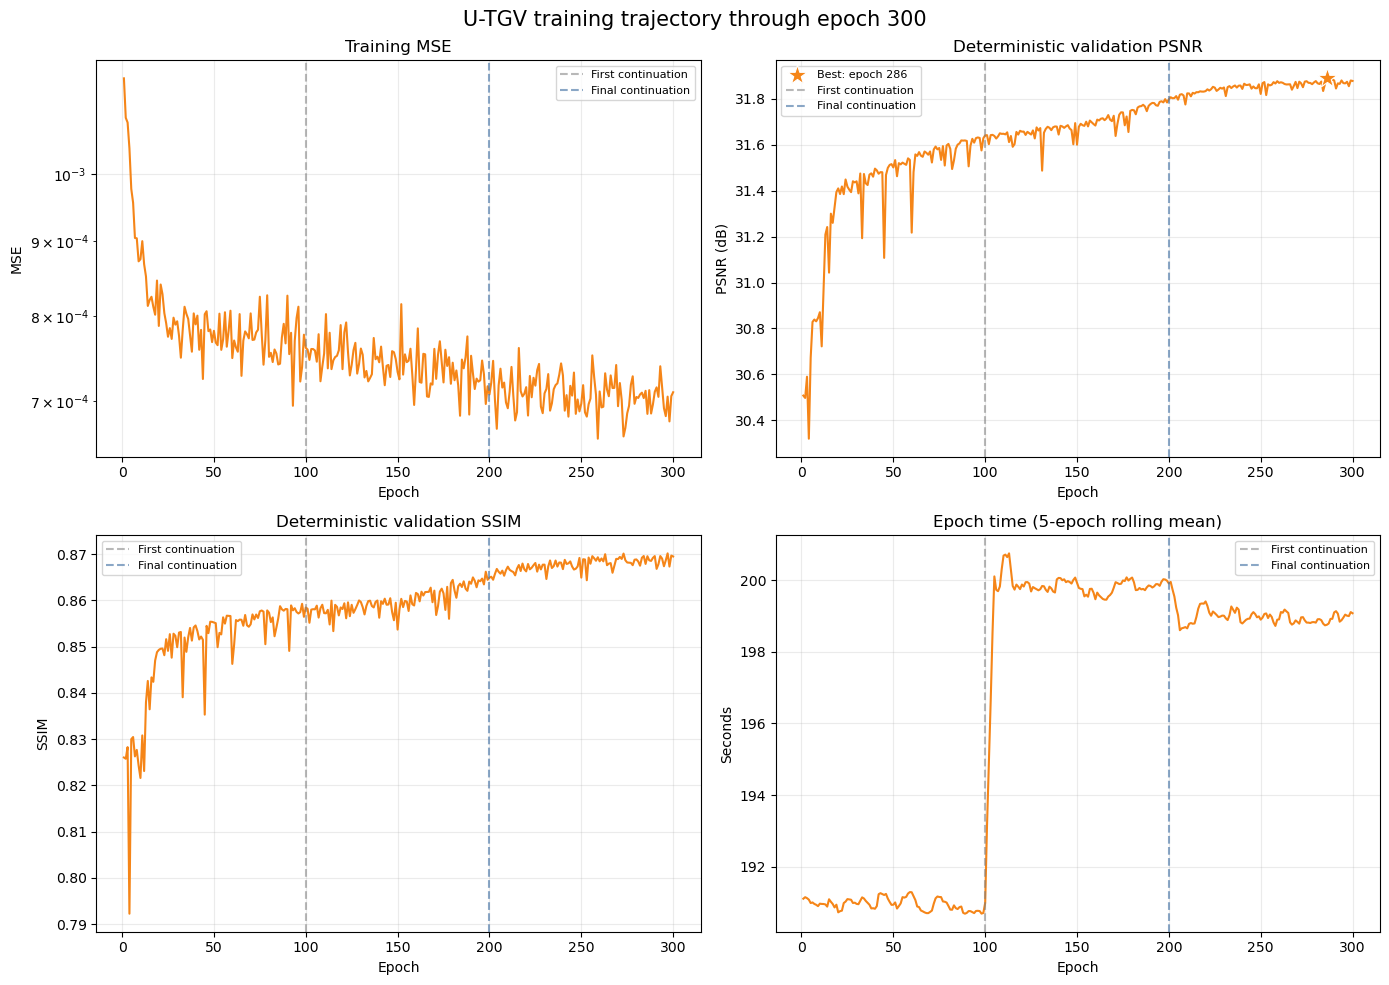

Saved: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline/results/training/u_tgv_e300_training_curves.png


In [12]:
figure, axes = plt.subplots(2, 2, figsize=(14, 10))
color = "#F58518"

axes[0, 0].plot(verified_history["epoch"], verified_history["train_mse"], color=color)
axes[0, 1].plot(verified_history["epoch"], verified_history["val_psnr"], color=color)
axes[1, 0].plot(verified_history["epoch"], verified_history["val_ssim"], color=color)
rolling_time = verified_history["epoch_time_sec"].rolling(5, min_periods=1).mean()
axes[1, 1].plot(verified_history["epoch"], rolling_time, color=color)

axes[0, 1].scatter(
    best_epoch,
    best_psnr,
    marker="*",
    s=220,
    color=color,
    edgecolor="white",
    linewidth=0.8,
    zorder=5,
    label=f"Best: epoch {best_epoch}",
)

for axis in axes.flat:
    axis.axvline(100, color="#7F7F7F", linestyle="--", alpha=0.55, label="First continuation")
    axis.axvline(200, color="#4C78A8", linestyle="--", alpha=0.65, label="Final continuation")
    axis.grid(alpha=0.25)

axes[0, 0].set(title="Training MSE", xlabel="Epoch", ylabel="MSE")
axes[0, 0].set_yscale("log")
axes[0, 1].set(title="Deterministic validation PSNR", xlabel="Epoch", ylabel="PSNR (dB)")
axes[1, 0].set(title="Deterministic validation SSIM", xlabel="Epoch", ylabel="SSIM")
axes[1, 1].set(title="Epoch time (5-epoch rolling mean)", xlabel="Epoch", ylabel="Seconds")
for axis in axes.flat:
    handles, labels = axis.get_legend_handles_labels()
    if handles:
        unique = dict(zip(labels, handles))
        axis.legend(unique.values(), unique.keys(), fontsize=8)

figure.suptitle("U-TGV training trajectory through epoch 300", fontsize=15)
figure.tight_layout()
curve_path = results_dir / "u_tgv_e300_training_curves.png"
figure.savefig(curve_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close(figure)
print("Saved:", curve_path)


Summarises U-TGV's final validation trend to assess whether improvement remains material near epoch 300.

In [13]:
trend_rows = []
for window in (20, 50):
    recent = verified_history.tail(window)
    slope = float(np.polyfit(recent["epoch"], recent["val_psnr"], 1)[0])
    trend_rows.append({
        "window_epochs": window,
        "psnr_slope_db_per_epoch": slope,
        "estimated_change_over_window_db": slope * (window - 1),
        "window_start_epoch": int(recent["epoch"].iloc[0]),
        "window_end_epoch": int(recent["epoch"].iloc[-1]),
    })

trend_summary = pd.DataFrame(trend_rows)
trend_path = results_dir / "u_tgv_e300_recent_validation_trend.csv"
atomic_dataframe_csv(trend_summary, trend_path)
display(trend_summary)
print("Saved:", trend_path)


,window_epochs,psnr_slope_db_per_epoch,estimated_change_over_window_db,window_start_epoch,window_end_epoch
0,20,0.000317,0.006032,281,300
1,50,0.000238,0.011660,251,300


Saved: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline/results/training/u_tgv_e300_recent_validation_trend.csv


U-TGV validation PSNR remained positively sloped through the original
200-epoch cap, with its best checkpoint at epoch 198. Its training budget was
therefore extended, using validation information only, to a pre-specified
final cap of 300 epochs. The epoch-200 network, AdamW state, complete history
and saved random-number-generator states were restored. The data split,
stochastic training-noise process, deterministic validation set,
architecture, PDHG depth and optimisation hyperparameters were unchanged.
The final U-TGV model was selected as the checkpoint with the highest
deterministic validation PSNR over the complete 300-epoch trajectory.
